# Entropi, temperatur og Boltzmann-fordelingen

:::{admonition} Læringsmål
:class: note
Etter å ha arbeidet med dette kapitlet skal du kunne:

- forklare sammenhengen mellom multiplisitet og Boltzmanns entropi
- beregne multiplisiteten og entropien for enkle systemer
- bruke sannsynlighetsargumenter til å forklare likevekt og retningen til spontane prosesser
- forklare det statistiske grunnlaget for termodynamikkens andre lov
- forklare hvordan temperatur knytter sammen energi og entropi
- gjøre rede for betydningen av Boltzmann-fordelingen
:::

Når et egg først er knust, samler det seg ikke igjen. En bakt kake blir ikke rå, og rust dannes lettere enn den forsvinner. Kroppene våre eldes. Prosessene kan gå med svært ulik hastighet, og noen kan bremses, men de har en foretrukket retning. Hvorfor? En viktig del av svaret ligger i fenomenet _entropi_.

Entropi er ett av de begrepene i kjemien som lett kan virke abstrakt og unnvikende. Det blir ofte knyttet til «uorden», men det ordet forklarer verken hvorfor varme strømmer fra varmt til kaldt, eller hvorfor en gass fyller beholderen den slippes fri i. Den statistiske tolkningen gir oss en mer presis forklaring: Vi må undersøke hvor mange mikroskopiske måter hver makroskopiske tilstand kan realiseres på.

I dette kapitlet tar vi den mikroskopiske veien inn i entropibegrepet. Den østerrikske fysikeren Ludwig Boltzmann viste på slutten av 1800-tallet at entropi har en dyp statistisk betydning. For et isolert system der de tilgjengelige mikrotilstandene er like sannsynlige, er **entropi et mål på antall mikroskopiske måter systemet kan realisere sin makroskopiske tilstand på**. Jo flere måter, desto høyere entropi og desto mer sannsynlig er tilstanden.

:::{admonition} Kapitlet i et nøtteskall
:class: note
Energien bestemmes av hvilke energinivåer partiklene befinner seg på, entropien forteller hvor mange mikrotilstander som gir samme makrotilstand, og temperaturen styrer hvilke energifordelinger som er sannsynlige.
:::

:::{admonition} Tenk over før du går videre
:class: tip
Hva forbinder du med entropi fra før? Prøv også å formulere hvorfor det er utilstrekkelig å si at entropi bare er «uorden».
:::


## Fra multiplisitet til entropi

Vi repeterer kort utgangspunktet fra [introduksjonen](https://andreasdh.github.io/Bifrost/docs/1_introduksjon.html): En **makrotilstand** beskriver systemet med noen få størrelser, mens en **mikrotilstand** angir den fullstendige tilstanden innenfor modellen vi bruker. Antallet mikrotilstander som er forenlige med en bestemt makrotilstand, kalles **multiplisiteten** og betegnes $\Omega$.

For et [isolert system](https://andreasdh.github.io/Bifrost/docs/1_introduksjon.html#system-og-omgivelser) med fast energi, volum og partikkeltall behandles de tilgjengelige mikrotilstandene som like sannsynlige. En makrotilstand med stor $\Omega$ kan da realiseres på flere måter og observeres oftere enn en makrotilstand med liten $\Omega$. Boltzmann knyttet denne opptellingen til entropien:

:::{admonition} Boltzmanns entropi
:class: important

$$S=k_\mathrm{B}\ln\Omega$$

Her er $k_\mathrm{B}=1{,}380\,649\times10^{-23}\ \mathrm{J\,K^{-1}}$ Boltzmanns konstant.
:::

Logaritmen gjør entropien additiv. For to uavhengige delsystemer er

$$\Omega_\mathrm{tot}=\Omega_A\Omega_B$$

Dermed er

$$S_\mathrm{tot}=k_\mathrm{B}\ln(\Omega_A\Omega_B)=S_A+S_B$$

Entropi er derfor ikke ganske enkelt «uorden». I denne sammenhengen er entropi et mål på hvor mange mikroskopiske muligheter som er forenlige med den makroskopiske tilstanden.

:::{admonition} Underveisoppgave
:class: tip
Et system kan realisere makrotilstand A på 10 måter og makrotilstand B på 1000 måter.

1. Hvilken makrotilstand har størst entropi?
2. Regn ut $\Delta S=S_B-S_A$ uttrykt ved $k_\mathrm{B}$.
3. Hvorfor er ikke entropiforskjellen proporsjonal med $1000-10$?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Makrotilstand B har størst entropi. Forskjellen er

$$\Delta S=S_B-S_A=k_\mathrm{B}(\ln(\Omega_B)-\ln(\Omega_A))=k_\mathrm{B}\ln\!\left(\frac{B}{A}\right)=k_\mathrm{B}\ln\!\left(\frac{1000}{10}\right)=k_\mathrm{B}\ln100\approx4{,}61k_\mathrm{B}$$

Entropien avhenger av logaritmen til multiplisiteten. Det er forholdet mellom antall muligheter, ikke differansen mellom dem, som bestemmer entropiforskjellen.
:::


### Eksempel: gass i to kamre

Tenk deg en beholder delt i to like store kamre, $A$ og $B$, forbundet med en ventil. Til å begynne med er all gassen i kammer $A$, og ventilen er lukket. Så åpner vi ventilen. Vi vet alle hva som skjer: gassen fyller hele beholderen. Men *hvorfor* skjer det helt av seg selv, og hvorfor ser vi aldri det motsatte: at gassen spontant trekker seg tilbake til $A$?

For en ideell gass beveger molekylene seg uavhengig av hverandre. Når gassen har nådd likevekt og de to kamrene er like store, er hvert molekyl like sannsynlig i $A$ som i $B$. Man kan si at hvert molekyl er som et myntkast. Kron $=$ kammer $A$, mynt $=$ kammer $B$.

![Fri ekspansjon av en gass mellom to kamre](bilder/gass_mikro_makro.svg)

En sannsynlighetsfordeling for systemet kan se slik ut:

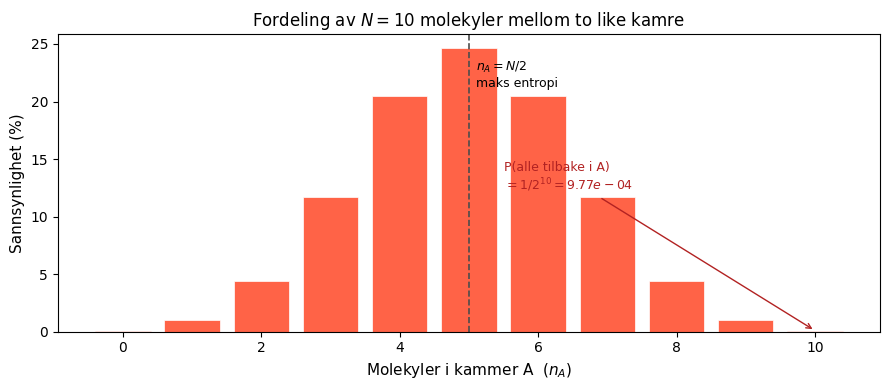

In [ ]:
from math import comb
import numpy as np
import matplotlib.pyplot as plt

BLA, ORANSJE = "#2b6cb0", "#c05621"

def omega_gass(N, nA):
    """Antall mikrotilstander for makrotilstanden 'nA molekyler i kammer A'."""
    return comb(N, nA)

def sannsynlighet_gass(N):
    """Analytisk fordeling P(nA) = C(N, nA) / 2**N."""
    nA = np.arange(0, N + 1)
    O  = np.array([omega_gass(N, int(k)) for k in nA], dtype=float)
    return nA, O / O.sum()          # summen er nettopp 2**N

def plott_gassfordeling(N):
    nA, P = sannsynlighet_gass(N)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(nA, P * 100, color=BLA, edgecolor='white', linewidth=0.5)
    ax.axvline(N / 2, color='0.3', ls='--', lw=1.2)
    ax.text(N / 2 + 0.1, P.max() * 100 * 0.96,
            r'$n_A = N/2$' + '\nmaks entropi', fontsize=9, va='top')
    ax.annotate(f'P(alle tilbake i A)\n$= 1/2^{{{N}}} = {P[-1]:.2e}$',
                xy=(N, P[-1] * 100), xytext=(N * 0.55, P.max() * 100 * 0.5),
                fontsize=9, color=ORANSJE,
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=1))
    ax.set_xlabel(r'Molekyler i kammer A  ($n_A$)', fontsize=11)
    ax.set_ylabel('Sannsynlighet (%)', fontsize=11)
    ax.set_title(f'Fordeling av $N = {N}$ molekyler mellom to like kamre')
    plt.tight_layout()
    plt.show()

plott_gassfordeling(10)

Fordelingen topper seg der molekylene er jevnt fordelt ($n_A = N/2$), og faller bratt mot kantene. Tilstanden «alle molekyler i $A$» ($n_A = N$) er bare *én* av $2^N$ mikrotilstander. Allerede med $N = 10$ molekyler er sannsynligheten for at gassen spontant samler seg i $A$ igjen under **0,1 %**. Det er dette som gjør fri ekspansjon irreversibel — det er ikke en kraft som drar molekylene utover, men det er rett og slett mange flere muligheter for at det skal skje!

Toppen ved $n_A=N/2$ er systemets **likevektsområde**: Det er her multiplisiteten og entropien er størst. Likevekt betyr ikke at molekylene slutter å bevege seg, eller at $n_A$ blir stående nøyaktig på $N/2$. Systemet skifter hele tiden mikrotilstand, og $n_A$ varierer rundt den mest sannsynlige verdien.

Når $N$ øker, blir fordelingen bredere målt i antall molekyler, men smalere målt i forhold til systemets størrelse. Det er denne stadig mindre *relative bredden* som gjør likevektstilstanden forutsigbar i et makroskopisk system.

Simuleringen nedenfor viser $N$ molekyler i en beholder med en ventil i midten. Molekylene starter i kammer $A$ med ventilen lukket. Åpne ventilen og se gassen spre seg. Histogrammet til høyre bygger seg opp over tid og viser den observerte fordelingen av $n_A$ (blå søyler), mens den oransje kurven er den teoretiske fordelingen. Med preset-knappene kan du skalere $N$ opp og se hvordan dette påvirker systemet.

In [2]:
from IPython.display import IFrame
import base64

with open("Simuleringer/gassimulering.html", "r", encoding="utf-8") as f:
    innhold = f.read()

encoded = base64.b64encode(innhold.encode("utf-8")).decode("utf-8")
IFrame(f"data:text/html;base64,{encoded}", width="100%", height=860)


:::{admonition} Underveisoppgave
:class: tip
Bruk simuleringen til å svare. Skriv gjerne ned observasjonene underveis. «Start på nytt»
nullstiller alt, og histogrammet tømmes også når du bytter $N$.

**A. Fri ekspansjon.** Velg $N = 20$. Før du åpner ventilen: hva er $n_A$, og hva er $\Omega$?
Åpne ventilen. Hvilken vei går molekylene først, og hva skjer med $n_A$ og $\Omega$ etter hvert?
Legger $n_A$ seg helt i ro på $N/2$?

**B. Sammenlign med teorien.** La den kjøre en stund. Hvor godt følger de blå søylene den
oransje kurven, og hvor ligger toppen? Kurven er $\Omega(n_A)/2^N$. Hvorfor er det nettopp den
fordelingen søylene skal nærme seg?

**C. Sjeldne hendelser.** Velg $N = 4$. Hvor ofte havner alle fire molekylene i $A$ samtidig?
Sammenlign med $1/2^4$. Regn så ut det samme for $N = 100$: hvor mange observasjoner måtte du
i snitt gjøre, og hvor lenge ville du holdt på med hundre observasjoner i sekundet?

**D. Oppskalering.** Gå fra $N = 4$ til $20$ til $100$. Blir fordelingen bredere eller smalere
målt i antall molekyler? Og målt mot hele aksen fra $0$ til $N$? Hva skjer med $\Omega_{maks}$?

**E. Andre lov.** For hvilke $N$ ser ekspansjonen ut som en lov, og for hvilke ser du tydelige
tilbakeslag? Hva sier det om termodynamikkens andre lov?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

**A.** Med ventilen lukket er $n_A = 20$ og $\Omega = 1$. Det finnes bare én måte å ha alle
molekylene i $A$ på. Når ventilen åpnes, går nettostrømmen mot $B$, rett og slett fordi det
er tjue kandidater på venstre side og ingen på høyre. $n_A$ synker mot 10, og $\Omega$ vokser
til $\Omega_{maks} = 184\,756$. Men $n_A$ blir ikke liggende i ro. Den svinger et par molekyler
opp og ned rundt 10, med typisk størrelse $\sigma = \sqrt{N}/2 \approx 2{,}2$.

Legg merke til at ingenting i bevegelsesreglene endret seg. Hvert molekyl spretter som før.
Det som endret seg, er hvor mange mikrotilstander makrotilstanden har.

**B.** Søylene legger seg på kurven, med toppen på $n_A = N/2 = 10$. Ved likevekt, når ventilen er åpen og
kamrene er like store, er hvert molekyl like sannsynlig i $A$ som i $B$. Hver mikrotilstand
har da sannsynlighet $2^{-N}$, og makrotilstanden $n_A$ rommer $\Omega(n_A) = \binom{N}{n_A}$
av dem. Sannsynligheten for makrotilstanden blir derfor $\binom{N}{n_A}/2^N$, altså kurven.
Tilpasningen blir bedre jo lenger den får kjøre. To praktiske forbehold: statistikken starter
først når gassen har rukket å spre seg, og påfølgende målinger er korrelerte i tid, så det tar
lengre tid å konvergere enn $N$ uavhengige myntkast ville gjort.

**C.** For $N = 4$ er $\Omega_{tot} = 2^4 = 16$, og bare én mikrotilstand har alle i $A$. Altså
$P = 1/16 = 6{,}25\ \%$, omtrent én av seksten observasjoner. Det er den lille søyla helt til
høyre i histogrammet, og den er like høy som søyla helt til venstre, som er tilfellet der alle
er i $B$.

For $N = 100$ er $P = 1/2^{100} = 7{,}9 \cdot 10^{-31}$, altså i snitt $1{,}3 \cdot 10^{30}$
observasjoner. Med hundre i sekundet tar det $4 \cdot 10^{20}$ år, omtrent tretti milliarder ganger
universets alder. Hendelsen er ikke forbudt, men observeres for alle praktiske formål aldri.

**D.** Bredden i antall molekyler vokser: $\sigma = \sqrt{N}/2$ gir 1, 2,2 og 5. Bredden målt mot
aksen krymper: $\sigma/\langle n_A \rangle = 1/\sqrt{N}$ gir 50 %, 22 % og 10 %. Det er derfor
toppen ser skarpere og skarpere ut selv om den faktisk blir bredere. $\Omega_{maks}$ vokser
eksplosivt: 6, deretter $184\,756$, deretter omtrent $10^{29}$. For ett mol er
$1/\sqrt{N}\approx10^{-12}$, så den relative svingningen er forsvinnende liten på makroskopisk nivå.

**E.** Med $N = 4$ ser du regelmessig at alt samler seg i det ene kammeret. Med $N = 20$ er store
avvik sjeldne, men $n_A = 15$ dukker opp innimellom. Med $N = 100$ ser du aldri noe langt fra 50.

Dette viser det statistiske grunnlaget for den andre loven. I et makroskopisk system framstår
ekspansjonen som en lovmessighet fordi tilbakeslag er overveldende usannsynlige, selv om de
mikroskopiske bevegelseslovene ikke foretrekker én tidsretning. Irreversibiliteten på makronivå
ligger i opptellingen.

:::

### Eksempel: Energi fordelt på to og tre nivåer

I gasseksemplet beskrev mikrotilstanden hvilket kammer hvert molekyl befant seg i. Nå ser vi på en annen enkel modell: $N$ partikler som kan befinne seg på noen få bestemte energinivåer. Vi begynner med et system med to nivåer. Det nederste nivået har energi $0$, mens det øverste har energi $\varepsilon$.

I denne enkle tellingsmodellen behandler vi partiklene som **skjelnbare**: Dersom to bestemte partikler bytter energinivå, teller det som en ny mikrotilstand. Vi antar også at hvert energinivå svarer til én mulig tilstand. Dersom flere ulike tilstander hadde hatt samme energi, ville energinivået vært {ref}`degenerert <degenerasjon>`.

Tenk deg at vi har fire partikler. Dersom tre partikler er på det nederste nivået og én er på det øverste, kan vi beskrive fordelingen som

$$(n_0,n_1)=(3,1)$$

Her forteller $n_0$ hvor mange partikler som har energi $0$, og $n_1$ hvor mange som har energi $\varepsilon$. Til sammen er det fire partikler.

Totalenergien er i dette tilfellet

$$E=3\cdot0+1\cdot\varepsilon=\varepsilon$$

Fordelingen forteller bare hvor mange partikler som er på hvert nivå. Mikrotilstanden forteller i tillegg hvilken av de fire partiklene som er eksitert. Det finnes derfor fire forskjellige mikrotilstander som gir fordelingen $(3,1)$.

Antallet mikrotilstander som gir en bestemt fordeling, kalles multiplisiteten $\Omega$. For fordelingen $(3,1)$ er dermed $\Omega=4$.

Med to nivåer bestemmer energien fordelingen fullstendig. Hvis $n$ partikler er på det øverste nivået, er

$$E=n\varepsilon$$

Når vi legger til et tredje nivå med energi $2\varepsilon$, blir situasjonen litt mer interessant. Den samme totalenergien kan nå oppstå fra forskjellige fordelinger. Energien $E=2\varepsilon$ kan for eksempel lages ved at

- to partikler har energi $\varepsilon$
- én partikkel har energi $2\varepsilon$

Disse fordelingene har samme energi, men de kan ha ulik multiplisitet og dermed ulik entropi.

Simuleringen nedenfor lar deg utforske forskjellen mellom mikrotilstand, fordeling, energi og multiplisitet.

In [1]:
from IPython.display import HTML

with open("Simuleringer/niva-multiplisitet.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)


Øverste del av simuleringen viser én mikrotilstand. Tallene under viser fordelingen, energien og multiplisiteten. Diagrammet nederst viser hvor mange mikrotilstander som finnes ved de ulike energiene. Diagrammet er en opptelling, ikke i seg selv en sannsynlighetsfordeling ved en bestemt temperatur. For å finne sannsynligheten ved fast temperatur må multiplisiteten også kombineres med Boltzmann-faktoren.

:::{admonition} Underveisoppgave
:class: tip

**A. To nivåer.** Velg to nivåer og $N=8$. Lag tilstander med henholdsvis $n=0$, $n=2$ og $n=4$ eksiterte partikler. Noter energien og multiplisiteten. Hvor er $\Omega$ størst? Trykk flere ganger på «Ny mikrotilstand (samme fordeling)». Hva endres, og hva er uendret?

**B. Multiplisitet og systemstørrelse.** Sammenlikn diagrammet for $N=4$, $N=8$ og $N=16$. Blir toppen bredere eller smalere målt i antall eksiterte partikler? Hva skjer med bredden målt i forhold til hele systemet?

**C. Tre nivåer.** Velg tre nivåer og $N=4$. Lag energien $E=2\varepsilon$. Finn de to mulige fordelingene $(n_0,n_1,n_2)$ og multiplisiteten til hver av dem. Kontroller at summen er lik $\Omega(E)$. Trykk deretter mange ganger på «Ny mikrotilstand (samme energi)». Hvilken fordeling ser du oftest, og hvorfor?

**D. Fra fast energi til fast temperatur.** Simuleringen viser $\Omega(E)$ for et isolert system, men sier ikke direkte hvilken energi som er mest sannsynlig når systemet er i kontakt med et varmereservoar ved temperaturen $T$. Hvilken ekstra vekting tror du må tas med?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

**A.** For to nivåer er

$$\Omega(n)=\binom{N}{n}$$

Med $N=8$ får vi $\Omega(0)=1$, $\Omega(2)=28$ og $\Omega(4)=70$. Multiplisiteten er størst når partiklene er jevnest mulig fordelt mellom nivåene. Knappen for samme fordeling bytter hvilke partikler som er eksiterte. Mikrotilstanden endres, mens $n$, $E$ og $\Omega$ er uendret.

**B.** Den absolutte bredden i $n$ vokser som $\sqrt{N}/2$, men andelen $x=n/N$ får standardavviket $1/(2\sqrt{N})$. Fordelingen blir derfor smalere i forhold til systemets størrelse. For et stort system blir området rundt toppen ekstremt smalt relativt til systemets størrelse.

**C.** Ved $N=4$ og $E=2\varepsilon$ er de mulige fordelingene

$$ (n_0,n_1,n_2)=(2,2,0) $$

og

$$ (n_0,n_1,n_2)=(3,0,1) $$

Multiplisitetene er henholdsvis $4!/(2!2!)=6$ og $4!/(3!1!)=4$, slik at $\Omega(E)=6+4=10$. Når mikrotilstandene trekkes likt ved fast energi, kommer den første fordelingen i gjennomsnitt seks av ti ganger og den andre fire av ti ganger.

**D.** Ved en bestemt temperatur må multiplisiteten kombineres med en energivekt. Senere i kapitlet finner vi

$$P(E)\propto\Omega(E)e^{-E/k_\mathrm{B}T}$$

Multiplisiteten favoriserer energier med mange mikrotilstander, mens Boltzmann-faktoren demper høye energier. Temperaturen bestemmer balansen mellom disse hensynene.
:::


Vi kan nå oppsummere modellen mer generelt. La $n_i$ være antallet partikler på energinivået $\varepsilon_i$. Det totale partikkeltallet er da

$$N=\sum_i n_i$$

Den totale energien finner vi ved å multiplisere antallet partikler på hvert nivå med energien til nivået og summere bidragene:

$$E=\sum_i n_i\varepsilon_i$$

Med modellforutsetningene ovenfor – skjelnbare partikler og energinivåer som ikke er {ref}`degenererte <degenerasjon>` – er multiplisiteten til fordelingen

$$\Omega(\{n_i\})=\frac{N!}{\prod_i n_i!}$$

Telleren $N!$ teller alle mulige rekkefølger av de $N$ partiklene. Men en ombytting av partiklene som allerede befinner seg på det samme nivået, endrer ikke hvilke partikler som er på hvert nivå og gir derfor ikke en ny mikrotilstand. Derfor deler vi på $n_i!$ for hvert nivå. For fordelingen $(3,1)$ får vi for eksempel

$$\Omega(3,1)=\frac{4!}{3!1!}=4$$


## Termodynamikkens andre lov som statistisk lov

De små systemene ovenfor viser at systemet stadig skifter mikrotilstand, men som oftest befinner seg i makrotilstandene med størst multiplisitet, altså de som kan realiseres av flest mikrotilstander. Det som gjør termodynamikken *praktisk nyttig*, er at reelle systemer inneholder omtrent $10^{23}$ partikler. I et lite system kan det av og til oppstå tydelige fluktuasjoner bort fra den mest sannsynlige makrotilstanden. I et makroskopisk system blir slike variasjoner forsvinnende små relativt til systemets størrelse.

For et isolert system formuleres [termodynamikkens andre lov](https://andreasdh.github.io/Bifrost/docs/A1_grunnleggende_begreper.html#termodynamikkens-lover) som

$$\Delta S_\mathrm{tot}\geq0$$

for en spontan makroskopisk prosess. Den statistiske forklaringen er at makrotilstander med høy entropi svarer til langt flere mikrotilstander enn makrotilstander med lav entropi.

Når antallet partikler øker, vokser antallet mikrotilstander enormt, samtidig som sannsynlighetsfordelingen blir stadig smalere *relativt til systemets størrelse*. For den symmetriske tosidige modellen er middelverdien og standardavviket til antallet partikler i kammer $A$

$$\mu_{n_A}=\frac{N}{2}$$

$$\sigma_{n_A}=\frac{\sqrt{N}}{2}$$

For andelen $x=n_A/N$ er middelverdien $\mu_x=1/2$, mens standardavviket er

$$\sigma_x=\frac{1}{2\sqrt{N}}$$

Dersom bredden måles relativt til middelverdien, kanselleres faktoren $1/2$:

$$\frac{\sigma_x}{\mu_x}=\frac{1}{\sqrt{N}}$$

:::{admonition} Nyttige matematiske verktøy
:class: seealso

Hva er $N$, $\mu$ og $\sigma$? Du kan lese mer om dette i [6.4 Normalfordeling](https://andreasdh.github.io/Bifrost/docs/matematikk/statistikk.html#normalfordelingen). Resultatet ovenfor kan begrunnes i [6.5 Sentralgrenseteoremet](https://andreasdh.github.io/Bifrost/docs/matematikk/statistikk.html#sentralgrenseteoremet). Matematikken i detalj er ikke pensum, men et nyttig hjelpemiddel i forståelsen av statistikken vi presenterer her.
:::

For $N\approx10^{23}$ er dette omtrent $3\times10^{-12}$. Systemet skifter hele tiden mikrotilstand, men nesten alle mikrotilstandene vi observerer, tilhører makrotilstander svært nær entropimaksimum. En målbar, spontan reduksjon i total entropi er derfor ikke matematisk umulig, men så usannsynlig at den ikke observeres i et makroskopisk system.

:::{admonition} Viktig presisering
:class: note
Andre lov skyldes ikke en kraft som trekker systemet mot større entropi. Systemet utforsker tilgjengelige mikrotilstander, men et overveldende flertall av dem tilhører makrotilstander svært nær entropimaksimum.
:::

:::{admonition} Underveisoppgave
:class: tip
Forklar med egne ord hvorfor et svært lite system kan ha tydelige fluktuasjoner bort fra entropimaksimum, mens slike avvik ikke observeres som en vedvarende makroskopisk prosess.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
I et lite system er sannsynlighetsfordelingen relativt bred, og fluktuasjoner bort fra entropimaksimum kan derfor observeres. Når systemet blir makroskopisk, blir fordelingen svært smal relativt til systemets størrelse. Fluktuasjonene finnes fortsatt på molekylnivå, men et vedvarende makroskopisk avvik fra entropimaksimum er overveldende usannsynlig.
:::


### Energifordeling og termisk likevekt

I simuleringene ovenfor så vi at noen makrotilstander kan realiseres gjennom langt flere mikrotilstander enn andre. Systemet skifter hele tiden mikrotilstand, men observeres oftest i makrotilstandene med størst multiplisitet og entropi. 

Vi bruker nå det samme prinsippet på et system som består av to deler, A og B. Makrotilstanden beskriver denne gangen hvordan den totale energien er fordelt mellom delsystemene. Totalsystemet er isolert, men A og B kan utveksle energi. Hvis A har energien $U_A$, må resten av energien være i B:

$$U_B=U_\mathrm{tot}-U_A$$

For hver mulig energifordeling finnes det et bestemt antall mikrotilstander i A og et bestemt antall i B. En mikrotilstand for totalsystemet må angi mikrotilstanden til begge delsystemene. Multiplisitetene må derfor kombineres, og entropiene blir additive:

$$S_\mathrm{tot}=S_A+S_B$$

Den mest sannsynlige energifordelingen er den som gir flest mulige mikrotilstander for totalsystemet og dermed størst total entropi. Vi kan forstå maksimumspunktet ved å tenke oss at en liten energimengde flyttes fra B til A. Entropien til A vil da øke, mens entropien til B vil avta. Hvis økningen i $S_A$ er større enn reduksjonen i $S_B$, øker den totale entropien. Den opprinnelige energifordelingen kan da ikke ha vært den mest sannsynlige. Hvis reduksjonen i $S_B$ er størst, ville den totale entropien i stedet økt dersom energien ble flyttet den andre veien. Ved den mest sannsynlige energifordelingen må de to endringene akkurat oppveie hverandre. En liten omfordeling av energien kan da ikke øke den totale entropien ytterligere. Systemet er da i **termisk likevekt**. Figuren nedenfor viser dette for to systemer som deler en fast total energi.

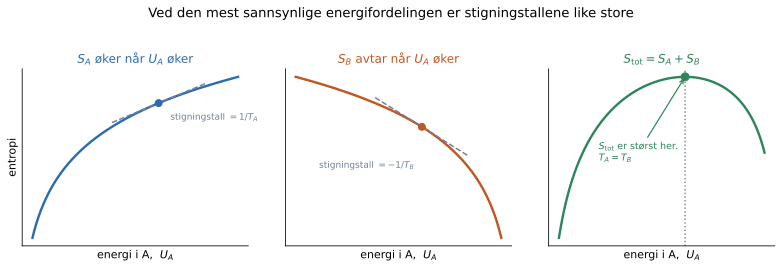

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import io
from IPython.display import SVG

BLA, ORANSJE, GRONN, GRA = "#2b6cb0", "#c05621", "#2f855a", "#718096"

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

# Modellsystemer med S(U) = C ln(U/U_0). Maksimum ligger der U_A/U_B = C_A/C_B.
C_A, C_B, U_tot, U_0 = 3.0, 2.0, 10.0, 1.0
U_A = np.linspace(0.6, U_tot - 0.6, 400)
U_B = U_tot - U_A

S_A, S_B = C_A * np.log(U_A / U_0), C_B * np.log(U_B / U_0)
S_tot = S_A + S_B

U_stj = U_tot * C_A / (C_A + C_B)                       # = 6.0
S_stj = C_A * np.log(U_stj / U_0) + C_B * np.log((U_tot - U_stj) / U_0)


def tangent(ax, x0, f, df, lengde=2.0):
    """Tegner tangenten til f i punktet x0."""
    xs = np.array([x0 - lengde, x0 + lengde])
    ax.plot(xs, f(x0) + df(x0) * (xs - x0), color=GRA, lw=1.5, ls="--", zorder=4)


fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True)

# --- A vinner entropi når den får energi ---
ax = axes[0]
ax.plot(U_A, S_A, color=BLA, lw=2.4)
tangent(ax, U_stj, lambda u: C_A * np.log(u / U_0), lambda u: C_A / u)
ax.plot(U_stj, C_A * np.log(U_stj / U_0), "o", color=BLA, ms=7, zorder=5)
ax.text(U_stj + 0.5, C_A * np.log(U_stj / U_0) - 0.85, r"stigningstall $=1/T_A$",
        color=GRA, fontsize=9)
ax.set_title(r"$S_A$ øker når $U_A$ øker", color=BLA)
ax.set_ylabel("entropi")

# --- B taper like mye ---
ax = axes[1]
ax.plot(U_A, S_B, color=ORANSJE, lw=2.4)
tangent(ax, U_stj, lambda u: C_B * np.log((U_tot - u) / U_0), lambda u: -C_B / (U_tot - u))
ax.plot(U_stj, C_B * np.log((U_tot - U_stj) / U_0), "o", color=ORANSJE, ms=7, zorder=5)
ax.text(U_stj - 4.4, C_B * np.log((U_tot - U_stj) / U_0) - 1.4, r"stigningstall $=-1/T_B$",
        color=GRA, fontsize=9)
ax.set_title(r"$S_B$ avtar når $U_A$ øker", color=ORANSJE)

# --- summen er flat i maksimum ---
ax = axes[2]
ax.plot(U_A, S_tot, color=GRONN, lw=2.4)
ax.axvline(U_stj, color=GRA, ls=":", lw=1.4)
ax.plot(U_stj, S_stj, "o", color=GRONN, ms=8, zorder=5)
ax.annotate("$S_\\mathrm{tot}$ er størst her.\n$T_A = T_B$",
            xy=(U_stj, S_stj), xytext=(U_stj - 3.7, S_stj - 2.7),
            color=GRONN, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=GRONN, lw=1.2))
ax.set_title(r"$S_\mathrm{tot}=S_A+S_B$", color=GRONN)

for ax in axes:
    ax.set_xlabel(r"energi i A,  $U_A$")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Ved den mest sannsynlige energifordelingen er stigningstallene like store",
             y=1.03)
fig.tight_layout()

buf = io.StringIO()
fig.savefig(buf, format="svg", transparent=True, bbox_inches="tight")
plt.close(fig)
SVG(data=buf.getvalue())

Legg merke til de to stiplede tangentene. I maksimumspunktet er de like bratte,
men peker hver sin vei. Det A vinner i entropi ved å få litt energi, taper B
nøyaktig like mye av. Nettopp derfor er den totale entropien flat akkurat der.

Begge de første panelene bruker $U_A$ på den horisontale aksen. Når $U_A$ øker, må $U_B$ avta like mye. Derfor har kurven i midtpanelet helningen $dS_B/dU_A=-1/T_B$. Måler vi i stedet endringen med hensyn på Bs egen energi, er helningen $\partial S_B/\partial U_B=1/T_B$. Det er denne positive deriverte som inngår i likevektsbetingelsen nedenfor.


Størrelsen

$$\left(\frac{\partial S}{\partial U}\right)_{V,N}$$

forteller hvor mye entropien endres når systemet får litt mer energi. Betingelsen for termisk likevekt er derfor

$$\left(\frac{\partial S_A}{\partial U_A}\right)_{V_A,N_A}=\left(\frac{\partial S_B}{\partial U_B}\right)_{V_B,N_B}$$

Termisk likevekt oppstår altså når en liten energimengde har den samme betydningen for entropien i begge delsystemene.

Likevekt betyr ikke at energien er låst i én bestemt fordeling. I et lite system kan energi fortsatt utveksles mellom A og B. Systemet befinner seg likevel oftest nær fordelingen med størst total entropi. Når systemet blir større, blir disse variasjonene stadig mindre i forhold til den totale energien, og likevekten blir mer tydelig.


## Temperatur

Vi har nå kommet fram til en størrelse som har samme verdi i begge delsystemene ved termisk likevekt. Denne størrelsen beskriver hvor mye entropien endres når energien til systemet øker. På den absolutte temperaturskalaen defineres den som den inverse temperaturen, og dette gir oss dermed en definisjon av temperatur som er begrunnet mikroskopisk, ut i fra tilgjengelige mikrotilstander:

:::{admonition} Temperatur
:class: important

$$\frac{1}{T}=\left(\frac{\partial S}{\partial U}\right)_{V,N}$$

:::

Temperatur er dermed et mål på sammenhengen mellom energi og entropi:

- Stor $\partial S/\partial U$ betyr at litt ekstra energi gir en stor økning i entropien. Da er temperaturen lav.
- Liten $\partial S/\partial U$ betyr at litt ekstra energi gir en mindre økning i entropien. Da er temperaturen høy.

Betingelsen for termisk likevekt kan derfor skrives som

$$T_A=T_B$$

Betingelsen $T_A=T_B$ forteller hvor systemet ender, men den samme tankegangen forteller også hvilken vei energien går. Hvis A er varmere enn B, gir en liten energioverføring fra A til B en større entropiøkning i B enn entropireduksjonen i A. Den totale entropien øker derfor når A avgir energi og B tar imot.

Energi går altså spontant fra varmt til kaldt, fordi denne energifordelingen kan realiseres av flere mikrotilstander. Det er multiplisiteten som bestemmer retningen, akkurat som da gassen fylte begge kamrene i tokammersystemet.

Etter hvert som temperaturene nærmer seg hverandre, blir gevinsten i total entropi mindre. Ved $T_A=T_B$ er ingen retning statistisk foretrukket. Nettostrømmen stopper, men små energiutvekslinger fortsetter, som _fluktasjoner_.

:::{admonition} Termisk likevekt
:class: important

Termisk likevekt er den mest sannsynlige fordelingen av energien mellom delsystemer i kontakt. Ved denne fordelingen er den totale entropien maksimal og delsystemene har samme temperatur. Systemet  vil likevel konstant fortsatt skifte mikrotilstand og utveksle små energimengder rundt denne fordelingen.
:::

:::{dropdown} Hvor kommer temperaturdefinisjonen fra?

La delsystemene A og B kunne omfordele energi, mens totalsystemets energi er konstant:

$$U_\mathrm{tot}=U_A+U_B$$

Hvis system A mottar en liten energimengde, må system B miste den samme energimengden:

$$dU_B=-dU_A$$

Endringen i den totale entropien er

$$dS_\mathrm{tot}=dS_A+dS_B$$

Ved konstant volum og partikkeltall kan entropiendringene skrives som

$$dS_A=\left(\frac{\partial S_A}{\partial U_A}\right)_{V_A,N_A}dU_A$$

$$dS_B=\left(\frac{\partial S_B}{\partial U_B}\right)_{V_B,N_B}dU_B$$

Når vi bruker at $dU_B=-dU_A$, får vi

$$dS_\mathrm{tot}=\left[\left(\frac{\partial S_A}{\partial U_A}\right)_{V_A,N_A}-\left(\frac{\partial S_B}{\partial U_B}\right)_{V_B,N_B}\right]dU_A$$

Ved termisk likevekt er den totale entropien maksimal. En liten omfordeling av energien kan da ikke øke entropien ytterligere. Derfor må

$$\left(\frac{\partial S_A}{\partial U_A}\right)_{V_A,N_A}=\left(\frac{\partial S_B}{\partial U_B}\right)_{V_B,N_B}$$

Vi har dermed funnet en størrelse som får samme verdi i begge delsystemene ved termisk likevekt. På den absolutte temperaturskalaen defineres denne størrelsen som den inverse temperaturen:

$$\frac{1}{T}=\left(\frac{\partial S}{\partial U}\right)_{V,N}$$ som betyr at ved likevekt så vil $$\frac{1}{T_A}=\left(\frac{\partial S_A}{\partial U_A}\right)_{V,N} = \left(\frac{\partial S_B}{\partial U_B}\right)_{V,N} = \frac{1}{T_A} $$ og dermed $$T_A =T_B$$

:::



Temperaturen forteller dermed hvor raskt antallet tilgjengelige mikrotilstander vokser når systemets energi øker.



## Fra entropimaksimum til Boltzmann-fordelingen

Termodynamikkens andre lov tilsier at et system utvikler seg mot den mest sannsynlige makrotilstanden, det vil si den tilstanden som kan realiseres av flest mikrotilstander. Når mikrotilstandene har ulike energier, kan ikke partiklene fordeles vilkårlig. Kravene om konstant partikkeltall og energi begrenser fordelingen. Den fordelingen som maksimerer entropien under disse betingelsene er Boltzmann-fordelingen.

## Entropi utrykt ved sannsynligheter: Gibbs´ definsjon 

Anta at $N_i$ partikler befinner seg i tilstand \(i\), slik at  $\sum_i N_i = N$

Antallet mikrotilstander som svarer til denne fordelingen er:
$$ W = \frac{N!}{\prod_i N_i!} $$

Fra Boltzmanns relasjon $ S = k_B \ln W $ og Stirlings approksimasjon som gir en veldig god tilnærming ved høye N: $\ln N! \approx N\ln N - N$ får vi $\ln W = N\ln N - \sum_i N_i \ln N_i. $
 
 Setter vi $$ p_i=\frac{N_i}{N}$$ slik at $$N_i=Np_i $$ finner vi $$\ln W = -N\sum_i p_i\ln p_i.$$ 
 
 Dermed blir entropien $$ \boxed{ S = -k_B N \sum_i p_i\ln p_i. } $$ 
 
 Per partikkel får vi  $$ \boxed{ S = -k_B \sum_i p_i\ln p_i. }$$ som kalles Gibbs definisjon av entropien. 
 
 Når alle mikrotilstander er like sannsynlige $p_i=1/\Omega$, reduseres dette til Boltzmanns formel $ S=k_B\ln\Omega. $


## Boltzmann fordelingen 


Anta at et system kan befinne seg i tilstander med energier $E_i$, og at sannsynligheten for tilstand $i$ er $p_i$. Ved å bruke Gibbs-entropien $$ S = -k_B \sum_i p_i \ln p_i $$ ønsker vi å finne sannsynlighetsfordelingen som maksimerer entropien under betingelsene 
$$ \sum_i p_i = 1, $$ og $$ \sum_i p_i E_i = \langle E\rangle = \text{konstant}. $$ 

Vi bruker et kjent triks fra matematikken og innfører Lagrange-multiplikatorene $\alpha$ og $\beta$: $$ \Phi = -k_B \sum_i p_i\ln p_i -\alpha \left( \sum_i p_i-1 \right) -k_B\beta \left( \sum_i p_iE_i-\langle E\rangle \right). $$ 

Ved maksimum må $$ \frac{\partial\Phi}{\partial p_i}=0, $$ slik at $$ -k_B(\ln p_i+1) -\alpha -k_B\beta E_i = 0. $$ Dermed $$ \ln p_i = -\frac{\alpha}{k_B} -1 -\beta E_i. $$ Dette gir $$ p_i = Ae^{-\beta E_i}, $$ der $A$ er en konstant. 

Normaliseringsbetingelsen $$ \sum_i p_i =1 $$ gir $$ A = \frac{1}{\sum_i e^{-\beta E_i}}. $$ 

Vi definerer  **partisjonsfunksjonen** $$ \boxed{ q = \sum_i e^{-\beta E_i}. } $$ Dermed får vi $$ \boxed{ p_i = \frac{e^{-\beta E_i}}{q} } $$ der $$ \boxed{ \beta = \frac{1}{k_B T}. } $$ Boltzmann-fordelingen er dermed den sannsynlighetsfordelingen som maksimerer entropien når middelenergien holdes konstant.



### Utforsk Boltzmann-fordelingen

Vi kan nå se hvordan Boltzmann-fordelingen endres med temperaturen. I simuleringen under har systemet seks tillatte, ikke degenererte energinivåer med samme avstand $\Delta\varepsilon$ mellom nivåene. Hvert nivå representerer dermed én mikrotilstand:

$$E_n=n\Delta\varepsilon$$

Sannsynligheten for hvert nivå bestemmes av Boltzmann-fordelingen

$$p_n=\frac{e^{-E_n/k_\mathrm{B}T}}{Q}$$

Hvis et nivå i stedet hadde vært degenerert med $g_n$ mikrotilstander, ville sannsynligheten for å finne systemet på dette energinivået vært proporsjonal med

$$P_n\propto g_n e^{-E_n/k_\mathrm{B}T}$$

Glidebryteren styrer forholdet $k_\mathrm{B}T/\Delta\varepsilon$. Dette sammenlikner den termiske energiskalaen $k_\mathrm{B}T$ med energiforskjellen mellom nivåene. Legg merke til at **energinivåene ikke flytter seg når temperaturen endres**. Det er sannsynligheten for å finne systemet på hvert nivå som endres. Søylene viser de normaliserte sannsynlighetene, slik at

$$\sum_n p_n=1$$

In [ ]:

from IPython.display import HTML

with open("Simuleringer/boltzmann_sim.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)

:::{admonition} Prøv selv: Boltzmann-fordelingen
:class: tip

1. Sett $k_\mathrm{B}T/\Delta\varepsilon$ svært lavt. Hvilket nivå har størst sannsynlighet?
2. Øk temperaturen. Endres de tillatte energinivåene, eller bare sannsynlighetene?
3. Finn omtrent når det første eksiterte nivået får en tydelig sannsynlighet.
4. Forklar hvorfor elektroniske og vibrasjonelle eksitasjoner ofte er mindre sannsynlige enn rotasjonelle eksitasjoner ved romtemperatur.
5. Kontroller at sannsynlighetene alltid summerer til 1.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Ved lav temperatur dominerer grunntilstanden. Temperaturen skaper ikke nye energinivåer; den endrer Boltzmann-vektene. Eksiterte nivåer får merkbar sannsynlighet når energigapet ikke lenger er stort sammenliknet med $k_\mathrm{B}T$. Vibrasjonelle og elektroniske energigap er ofte større enn rotasjonelle energigap og krever derfor høyere temperatur før de bidrar tydelig.
:::


## Videre til partisjonsfunksjonen

Boltzmann-fordelingen forteller hvordan energien vekter mikrotilstandene, men normaliseringsfaktoren $Q$ er fortsatt delvis uforklart. Så langt har vi sett at summen sørger for at sannsynlighetene blir 1. I [neste kapittel](3_partisjonsfunksjonen.ipynb) ser vi at den også knytter mikrotilstandenes energier til målbare størrelser som indre energi, entropi og varmekapasitet.

## Oppgaver

:::{admonition} Oppgave 1: Et to-nivåsystem
:class: tip

Åtte partikler kan befinne seg på energinivåene $0$ og $\varepsilon$. Tre av partiklene er eksiterte.

1. Finn totalenergien.
2. Beregn multiplisiteten.
3. Beregn entropien uttrykt ved $k_\mathrm{B}$.
4. Sammenlikn med makrotilstanden der fire partikler er eksiterte. Hvilken makrotilstand har størst entropi?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Totalenergien er

$$E=3\varepsilon$$

Multiplisiteten er

$$\Omega(3)=\binom{8}{3}=56$$

Entropien er

$$S=k_\mathrm{B}\ln56\approx4{,}03k_\mathrm{B}$$

Når fire partikler er eksiterte, er multiplisiteten

$$\Omega(4)=\binom{8}{4}=70$$

Denne makrotilstanden har derfor størst entropi. Entropien er størst når partiklene er fordelt så jevnt som mulig mellom de to nivåene.
:::


:::{admonition} Oppgave 2: Samme energi, ulike fordelinger
:class: tip

Fire partikler kan befinne seg på nivåene $0$, $\varepsilon$ og $2\varepsilon$. Totalenergien er $E=2\varepsilon$.

1. Finn alle mulige fordelinger $(n_0,n_1,n_2)$.
2. Beregn multiplisiteten til hver fordeling.
3. Finn den samlede multiplisiteten $\Omega(E)$.
4. Dersom alle mikrotilstander med denne energien er like sannsynlige, hva er sannsynligheten for hver av fordelingene?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

De mulige fordelingene er

$$(n_0,n_1,n_2)=(2,2,0)$$

og

$$(n_0,n_1,n_2)=(3,0,1)$$

Multiplisitetene er

$$\Omega(2,2,0)=\frac{4!}{2!2!}=6$$

$$\Omega(3,0,1)=\frac{4!}{3!1!}=4$$

Den samlede multiplisiteten ved denne energien er

$$\Omega(E)=6+4=10$$

Sannsynlighetene for de to fordelingene er dermed

$$P(2,2,0)=\frac{6}{10}=0{,}60$$

$$P(3,0,1)=\frac{4}{10}=0{,}40$$

Fordelingene har samme totalenergi, men ulik sannsynlighet fordi de kan realiseres gjennom ulikt antall mikrotilstander.
:::


:::{admonition} Oppgave 3: Et sporstoff fordeler seg i laboratoriet
:class: tip

Hundre sporstoffmolekyler slippes inn i kammer A i en beholder som består av to like store kamre. Deretter åpnes ventilen mellom kamrene. Når systemet har kommet til likevekt med ventilen åpen, er hvert molekyl like sannsynlig i A som i B.

1. Beregn multiplisiteten når alle molekylene er i A.
2. Beregn multiplisiteten når 50 molekyler er i hvert kammer.
3. Hvor mange ganger mer sannsynlig er fordelingen $50/50$ enn fordelingen der alle molekylene er i A?
4. Beregn sannsynligheten for hver av de to fordelingene.
5. Beregn standardavviket til antallet molekyler i A.
6. Beregn standardavviket til andelen $x=n_A/N$ og bredden relativt til middelverdien.
7. Forklar hvordan resultatene illustrerer termodynamikkens andre lov.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Når alle molekylene er i A, finnes det bare én mikrotilstand:

$$\Omega(100)=1$$

Når 50 molekyler er i hvert kammer, er multiplisiteten

$$\Omega(50)=\binom{100}{50}\approx1{,}01\times10^{29}$$

Fordelingen $50/50$ er derfor omtrent $10^{29}$ ganger mer sannsynlig enn fordelingen der alle molekylene er i A.

Det finnes totalt $2^{100}$ mikrotilstander. Sannsynlighetene blir dermed

$$P(100)=\frac{1}{2^{100}}\approx7{,}9\times10^{-31}$$

$$P(50)=\frac{\binom{100}{50}}{2^{100}}\approx0{,}0796$$

Standardavviket til antallet molekyler i A er

$$\sigma_{n_A}=\frac{\sqrt{N}}{2}=5$$

For andelen $x=n_A/N$ er standardavviket

$$\sigma_x=\frac{1}{2\sqrt{N}}=0{,}05$$

Middelverdien er $\mu_x=0{,}5$. Bredden relativt til middelverdien er derfor

$$\frac{\sigma_x}{\mu_x}=\frac{1}{\sqrt{N}}=0{,}10$$

Med hundre molekyler kan det fortsatt observeres tydelige fluktuasjoner. For ett mol molekyler er den relative bredden omtrent $10^{-12}$. Makrotilstander langt fra den jevne fordelingen er da ikke umulige, men så usannsynlige at de ikke observeres som vedvarende makroskopiske tilstander.
:::

:::{admonition} Oppgave 4: Konformasjoner av butan
:class: tip

Butan kan befinne seg i én transkonformasjon og to energimessig like gauchekonformasjoner. I en forenklet modell setter vi energien til transkonformasjonen lik null. Hver gauchekonformasjon ligger $3{,}8\ \mathrm{kJ\,mol^{-1}}$ høyere i energi.

Ved $298\ \mathrm{K}$ kan du bruke

$$RT=2{,}48\ \mathrm{kJ\,mol^{-1}}$$

1. Beregn Boltzmann-faktoren til én gauchekonformasjon relativt til transkonformasjonen.
2. Hvorfor må bidraget fra gauche multipliseres med 2?
3. Finn partisjonsfunksjonen for denne modellen.
4. Beregn sannsynligheten for trans og den samlede sannsynligheten for gauche.
5. Forklar hvordan energi og degenerasjon konkurrerer om å bestemme fordelingen.
6. Hvilke sannsynligheter nærmer konformasjonene seg ved svært høy temperatur?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Boltzmann-faktoren til én gauchekonformasjon relativt til trans er

$$e^{-\Delta E/RT}=e^{-3{,}8/2{,}48}\approx0{,}216$$

Det finnes to forskjellige gauchekonformasjoner med samme energi. Den samlede vekten til gauche blir derfor

$$2e^{-\Delta E/RT}\approx0{,}432$$

Partisjonsfunksjonen for de tre mikrotilstandene er

$$Q=1+2e^{-\Delta E/RT}\approx1{,}432$$

Sannsynligheten for trans er

$$P_\mathrm{trans}=\frac{1}{Q}\approx0{,}698$$

Den samlede sannsynligheten for gauche er

$$P_\mathrm{gauche}=\frac{2e^{-\Delta E/RT}}{Q}\approx0{,}302$$

Den lave energien favoriserer trans, mens det større antallet tilgjengelige gauchekonformasjoner favoriserer gauche. Fordelingen bestemmes av konkurransen mellom disse bidragene.

Ved svært høy temperatur nærmer alle de tre mikrotilstandene seg samme sannsynlighet. Da får vi

$$P_\mathrm{trans}\rightarrow\frac{1}{3}$$

$$P_\mathrm{gauche}\rightarrow\frac{2}{3}$$
:::


:::{admonition} Oppgave 5: Rotasjon og vibrasjon i HCl
:class: tip

Energigapet mellom de to laveste rotasjonsnivåene i HCl er omtrent $0{,}25\ \mathrm{kJ\,mol^{-1}}$. Energigapet mellom den vibrasjonelle grunntilstanden og den første vibrasjonelt eksiterte tilstanden er omtrent $35\ \mathrm{kJ\,mol^{-1}}$.

Ved $298\ \mathrm{K}$ kan du bruke $RT=2{,}48\ \mathrm{kJ\,mol^{-1}}$. Ved $600\ \mathrm{K}$ kan du bruke $RT=4{,}99\ \mathrm{kJ\,mol^{-1}}$.

1. Beregn Boltzmann-faktoren til én mikrotilstand på det første rotasjonelt eksiterte nivået relativt til rotasjonsgrunntilstanden ved $298\ \mathrm{K}$.
2. Rotasjonsgrunntilstanden er ikke degenerert, mens det første eksiterte rotasjonsnivået har degenerasjonen $g=3$. Beregn forholdet mellom den samlede populasjonen på de to nivåene.
3. Beregn forholdet mellom populasjonene i den første vibrasjonelt eksiterte tilstanden og vibrasjonsgrunntilstanden ved $298\ \mathrm{K}$. Anta at nivåene ikke er degenererte.
4. Gjenta beregningen for vibrasjon ved $600\ \mathrm{K}$.
5. Forklar hvorfor rotasjonelle eksitasjoner er vanlige ved romtemperatur, mens nesten alle HCl-molekylene er i den vibrasjonelle grunntilstanden.
6. Endrer temperaturen energinivåene eller sannsynligheten for å finne molekylene på nivåene?
7. Forklar med reservoarmodellen hvorfor en mikrotilstand med høy energi får en mindre Boltzmann-faktor.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

For én rotasjonelt eksitert mikrotilstand er forholdet

$$\frac{p_1}{p_0}=e^{-0{,}25/2{,}48}\approx0{,}904$$

Når vi tar hensyn til degenerasjonen til det eksiterte nivået, blir forholdet mellom nivåpopulasjonene

$$\frac{P_1}{P_0}=3e^{-0{,}25/2{,}48}\approx2{,}71$$

Det eksiterte rotasjonsnivået kan dermed ha større samlet populasjon enn grunntilstanden, selv om hver enkelt mikrotilstand på nivået har lavere sannsynlighet enn grunntilstanden.

For vibrasjon ved $298\ \mathrm{K}$ får vi

$$\frac{P_1}{P_0}=e^{-35/2{,}48}\approx7{,}4\times10^{-7}$$

Ved $600\ \mathrm{K}$ får vi

$$\frac{P_1}{P_0}=e^{-35/4{,}99}\approx9{,}0\times10^{-4}$$

Det rotasjonelle energigapet er lite sammenliknet med $RT$, mens det vibrasjonelle energigapet er mye større. Derfor er flere rotasjonsnivåer merkbart befolket ved romtemperatur, mens nesten alle molekylene befinner seg i den vibrasjonelle grunntilstanden.

Temperaturen endrer ikke de tillatte energinivåene i denne modellen. Den endrer sannsynligheten for å finne molekylene på nivåene.

Når molekylet befinner seg i en mikrotilstand med høy energi, må reservoaret ha tilsvarende mindre energi. Reservoaret får da færre tilgjengelige mikrotilstander. Derfor finnes det færre mikrotilstander for totalsystemet som er forenlige med den energirike mikrotilstanden til molekylet.
:::


:::{admonition} Oppgave 6: Vurder en simuleringsrapport
:class: tip

En student har brukt simuleringene i kapitlet og skrevet følgende konklusjon:

> Ved likevekt har systemet sluttet å skifte mikrotilstand. Når temperaturen øker, flyttes energinivåene oppover. Energien med størst multiplisitet er alltid mest sannsynlig. Når antallet partikler øker, blir sannsynlighetsfordelingen smalere målt i antall partikler.

Vurder hver av påstandene. Forklar hva som er feil eller upresist, og skriv en faglig bedre versjon.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Likevekt betyr ikke at systemet har sluttet å skifte mikrotilstand. Systemet fortsetter å bevege seg mellom mikrotilstander, men befinner seg oftest i makrotilstander nær den mest sannsynlige fordelingen.

Temperaturen flytter ikke energinivåene i modellene vi har brukt. Den endrer Boltzmann-faktorene og dermed sannsynligheten for å finne systemet på de ulike nivåene.

Energien med størst multiplisitet er ikke nødvendigvis mest sannsynlig når systemet har en bestemt temperatur. Sannsynligheten for en energi bestemmes av både multiplisiteten og Boltzmann-faktoren:

$$P(E)\propto\Omega(E)e^{-E/k_\mathrm{B}T}$$

Når antallet partikler øker, blir fordelingen vanligvis bredere målt i antall partikler:

$$\sigma_{n_A}=\frac{\sqrt{N}}{2}$$

Den blir samtidig smalere relativt til systemets størrelse:

$$\frac{\sigma_x}{\mu_x}=\frac{1}{\sqrt{N}}$$

Det er den stadig mindre relative bredden som gjør makroskopisk likevekt stabil og forutsigbar.
:::